# The purpose of this notebook is to take output TDI data, compute the datastream for the TDI-E channel, whiten and normalise it, split it into long-duration labelled training, validation and test data and train a CNN on it to identify the number of glitches present.

## _Imports and path definitions:_

In [130]:
#IMPORTS
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import os
import h5py
import numpy as np
import tensorflow as tf
from gwpy.timeseries import TimeSeriesDict
from gwpy.timeseries import TimeSeries
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from scipy.signal import windows
from scipy import stats
from sklearn import metrics
import scipy.ndimage as ndi
from librosa import cqt


PATH_src = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
PATH_bethLISA = os.path.abspath(os.path.join(PATH_src, os.pardir))
PATH_glitch_config = os.path.join(PATH_bethLISA, "dist/glitch_config/")
PATH_glitch_data = os.path.join(PATH_bethLISA, "dist/glitch_data/")
PATH_simulation_data = os.path.join(PATH_bethLISA, "dist/simulation_data/")
PATH_tdi_data = os.path.join(PATH_bethLISA, "dist/tdi_data/")
PATH_orbit_data = os.path.join(PATH_bethLISA, "dist/orbit_data/")
PATH_interferometer_plots = os.path.join(PATH_bethLISA,
                                         "dist/interferometer_plots/")

tdi_path = os.path.join(PATH_tdi_data, "default_tdi_output.h5")

## _Compute TDI-E data, whiten and normalise:_

TDI-E timeseries:  [0.0097322  0.0097322  0.0097322  ... 0.00973234 0.00973228
 0.0097322 ]
Number of samples in timeseries:  4147200


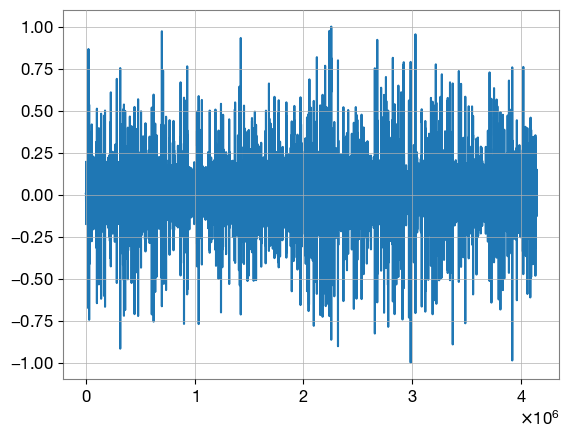

In [131]:
#READ TDI DATA, WHITEN, NORMALISE
tdi_path = os.path.join(PATH_tdi_data, "12d50gpd.h5")

tdiseries = h5py.File(tdi_path,'r')

def whiten(timeseries, eps=1e-8): #WHITEN THE TIMESERIES FROM SCRATCH
    timeseries = timeseries - np.mean(timeseries)
    fftseries = np.fft.fft(timeseries)
    magnitude = np.abs(fftseries)
    whitened_fft = fftseries / (magnitude + eps)
    whitened_timeseries = np.fft.ifft(whitened_fft).real
    return whitened_timeseries


def normalise(timeseries): #NORMALISE THE TIMESERIES USING MODIFIED MIN-MAX NORMALISATION. RESCALED TO [-1,1]
    return 2*((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries))) - 1

def minmaxnormalise(timeseries): #NORMALISE THE TIMESERIES USING MIN-MAX NORMALISATION. RESCALED TO [0,1]
    return ((timeseries-np.min(timeseries))/(np.max(timeseries)-np.min(timeseries)))

def moving_average(timeseries, kernelsize):
    return ndi.uniform_filter1d(timeseries, kernelsize, mode='constant', origin=-(kernelsize//2))[:-(kernelsize-1)]


tdiXarray = np.array(tdiseries["X"][:])
tdiYarray = np.array(tdiseries["Y"][:])
tdiZarray = np.array(tdiseries["Z"][:])

tdiE = (1/np.sqrt(6))*(tdiXarray-2*tdiYarray+tdiZarray)

tdiE = normalise(tdiE)

# tdiXarraynormal = normalise(tdiXarray)
# tdiYarraynormal = normalise(tdiYarray)
# tdiZarraynormal = normalise(tdiZarray)

# tdiXYZ = np.stack((tdiXarraynormal,tdiYarraynormal,tdiZarraynormal), axis=-1)

print('TDI-E timeseries: ', tdiE)
print('Number of samples in timeseries: ', len(tdiE))   
plt.plot(tdiE)

# plt.plot(tdiXYZ)


## _Get sorted list of injection times:_

In [132]:
#GET FILE PATH OF INJECTED GLITCH PARAMETERS FILE
glitch_output_path = os.path.join(PATH_glitch_data, '12d50gpd.txt')

#GET THE INJECTION TIMES IN A LIST, ORDERED AND IN UNITS OF SAMPLES
f = open(glitch_output_path, 'r')
glitch_output = f.readlines()[1:]

injection_times = []
for line in glitch_output:
    injection_times.append(4*(int(line.split(' ')[11])-10368000))

f.close()


injection_times = sorted(injection_times)
print('Injection times (in samples): ', injection_times)
print('Number of glitches: ', len(injection_times))


onehot_injection_times = np.zeros(len(tdiE))
for i in range(len(injection_times)):
    time = injection_times[i]
    onehot_injection_times[time] = 1

print(onehot_injection_times)
print(onehot_injection_times[20412])

    


Injection times (in samples):  [20412, 23140, 29488, 31896, 46808, 49352, 53396, 59188, 67572, 82552, 86312, 93284, 100784, 103900, 107944, 110980, 118744, 122492, 125884, 128392, 133564, 139436, 143452, 147568, 157008, 161972, 166008, 169368, 175516, 183388, 198908, 216000, 219852, 223484, 228680, 233052, 241032, 246188, 251516, 265356, 270660, 278820, 283764, 312592, 315320, 326740, 331240, 340784, 344164, 346908, 349568, 352808, 358608, 360732, 366108, 372444, 378544, 381096, 385424, 388052, 403784, 413728, 416568, 419440, 422528, 431812, 434896, 442076, 446824, 450716, 452880, 468120, 475244, 479816, 483980, 486844, 493196, 500444, 506680, 510728, 517260, 519640, 522176, 525872, 533840, 542276, 547604, 554540, 556992, 561544, 568580, 577560, 580824, 583420, 585520, 587620, 596704, 605312, 619196, 622240, 627860, 632724, 637260, 641328, 651900, 660192, 669428, 689580, 692232, 698224, 700360, 703732, 709452, 716000, 721140, 727632, 736900, 739148, 746132, 755004, 758804, 764392, 7689

## _Split timeseries into labelled training, validation and test data in the ratio 5:4:1 :_

In [133]:
#GENERALIZED CONSTANTS
sampling_rate = 4 
window_duration_sec = 600
window_size = window_duration_sec * sampling_rate
total_samples = len(tdiE)
num_windows = total_samples // window_size
gpd = 50

# RESHAPE TIMESERIES INTO MATRIX WITH 10 MINUTE SNIPPETS ON EVERY ROW
data = tdiE[:num_windows * window_size].reshape(num_windows, window_size, 1)

onehot_injection_times = np.array(onehot_injection_times)

labels = onehot_injection_times[:num_windows * window_size].reshape(num_windows, window_size,1)

# labels = np.zeros((num_windows,gpd))
# for i in range(len(labels)):
#     labels[i] = reshaped_injection_times[i] - i*345600




# #COUNT NUMBER OF INJECTIONS PER ROW
# labels = np.zeros(num_windows, dtype=np.int32)

# for i in range(num_windows):
#     start = i * window_size
#     end = (i + 1) * window_size
#     labels[i] = np.sum((injection_times >= start) & (injection_times < end))
    


# SHUFFLE THE TIMESERIES AROUND
indices = np.arange(num_windows)
np.random.shuffle(indices)

data = data[indices]
labels = labels[indices]

# SPLIT THE DATA INTO THE DIFFERENT SETS
train_size = int(0.6 * num_windows)
val_size = int(0.2 * num_windows)

train_data = data[:train_size]
train_labels = labels[:train_size]

validation_data = data[train_size:train_size + val_size]
validation_labels = labels[train_size:train_size + val_size]

test_data = data[train_size + val_size:]
test_labels = labels[train_size + val_size:]


print(test_labels)
# print(train_data)


print('Total number of timeseries: ', num_windows)
print('Number of items in training dataset: ', len(train_data))
print('Number of items in validation dataset: ', len(validation_data))
print('Number of items in test dataset: ', len(test_data))


[[[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]

 ...

 [[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  ...
  [0.]
  [0.]
  [0.]]]
Total number of timeseries:  1728
Number of items in training dataset:  1036
Number of items in validation dataset:  345
Number of items in test dataset:  347


# _Create architecture and train:_ 

In [134]:
model = models.Sequential([
    layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=(2400, 1)),
    layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.UpSampling1D(2),
    layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
    layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
    layers.UpSampling1D(2),
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    # layers.GlobalMaxPool1D(),
    # layers.Dropout(0.3),
    layers.Conv1D(1, 1, padding = 'same', activation='sigmoid')
    # layers.Dense(64, activation='relu'),
    # layers.Dense(64, activation='relu'),
    # layers.Dense(32, activation='relu'),
    # layers.Dense(50,activation='linear')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

model.fit(train_data, train_labels, validation_data=(validation_data, validation_labels), epochs=10, batch_size=40)

/opt/anaconda3/envs/CanaLISA/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_101 (Conv1D)             │ (None, 2400, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_102 (Conv1D)             │ (None, 2400, 32)       │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 1200, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_103 (Conv1D)             │ (None, 1200, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_104 (Conv1D)             │ (None, 1200, 64)       │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 600, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_10 (UpSampling1D) │ (None, 1200, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_105 (Conv1D)             │ (None, 1200, 32)       │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_106 (Conv1D)             │ (None, 1200, 32)       │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_11 (UpSampling1D) │ (None, 2400, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_107 (Conv1D)             │ (None, 2400, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_108 (Conv1D)             │ (None, 2400, 64)       │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_109 (Conv1D)             │ (None, 2400, 1)        │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,697 (194.13 KB)

 Trainable params: 49,697 (194.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.9998 - loss: 0.4825 - val_accuracy: 0.9999 - val_loss: 0.0045
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.9999 - loss: 0.0063 - val_accuracy: 0.9999 - val_loss: 0.0071
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.9999 - loss: 0.0064 - val_accuracy: 0.9999 - val_loss: 0.0036
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9999 - loss: 0.0029 - val_accuracy: 0.9999 - val_loss: 0.0015
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9999 - val_loss: 0.0015
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 0.9999 - val_loss: 0.0014
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9999 - val_loss: 0.0014
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.

# _Test accuracy on test data:_

In [135]:
#GET LOSS AND ACCURACY OF MODEL
loss, accuracy = model.evaluate(test_data, test_labels)

#GET PREDICTIONS IN A LIST 
result = model.predict(test_data)


erm = np.round(result)

print(np.count_nonzero(erm[0]))

SyntaxError: invalid syntax (1023039721.py, line 8)

0
2
0


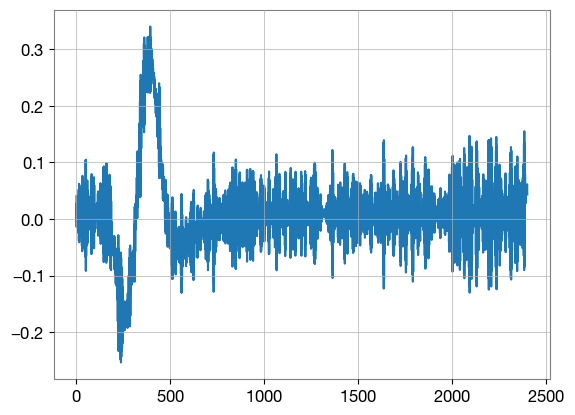

In [39]:
ts_of_interest = 121
print(test_labels[ts_of_interest - 1])
print(test_labels[ts_of_interest])
print(test_labels[ts_of_interest + 1])
# qspec = cqt(ts_of_interest,sr=4, fmin=0.05, n_bins=40)

# plt.imshow(abs(qspec),aspect='auto', origin='lower')
plt.plot(test_data[ts_of_interest])
